# 高校数学とJulia言語 Day 3

- 城北中学校・高等学校　中学3年・高校1年
- 夏期講習会III 2026/8/24~2026/8/28
- 担当：清水団

## 本日のテーマ:場合の数・組合せを実験しよう!

### 今年のテーマ「実験する高校数学」

- 整数は**探す**・場合の数は**全部作る**・関数は**描く**・確率は**試す**

### 5日間の学習予定

- **Day 1**：Google Colabの紹介・Juliaで計算しよう ✅
- **Day 2**：整数問題をプログラムで考えよう ✅
- **Day 3**：場合の数・組合せを実験しよう ← 今日
- **Day 4**：関数・グラフ・最大最小
- **Day 5**：確率・シミュレーション


## 今日のテーマ：「全部作る」

場合の数の授業では樹形図を書きますが、書き漏らしや数え間違いが心配……。

コンピュータなら**全部作って全部数える**ことができます。

- 樹形図の代わりに全パターンを生成
- 順列・組合せを「全部表示」してから公式へ
- パスカルの三角形に隠された驚きの模様

「数える前に、まず全部作る」が今日の合言葉です!

## 樹形図の代わりに全部生成しよう

**例題**：1, 2, 3 の数字を使って3桁の数を作る（同じ数字を何回使ってもよい）。全部で何通り?

樹形図を書く代わりに、for文を重ねて**全部作って**みましょう。

In [9]:
# 3重のfor文で全部生成!
for a in 1:3, b in 1:3, c in 1:3
    println("$a$b$c")
end

111
112
113
121
122
123
131
132
133
211
212
213
221
222
223
231
232
233
311
312
313
321
322
323
331
332
333


In [10]:
# 何通りあるか数える
cnt = 0
for a in 1:3, b in 1:3, c in 1:3
    cnt += 1
end
println("全部で $cnt 通り")

全部で 27 通り


$3 × 3 × 3 = 3^3 = 27$ 通り。**積の法則**が「見え」ましたか?

In [11]:
# 文字でもできる! コインを3回投げたときの表裏
for a in "表裏", b in "表裏", c in "表裏"
    println("$a$b$c")
end

表表表
表表裏
表裏表
表裏裏
裏表表
裏表裏
裏裏表
裏裏裏


In [12]:
# 条件をつけて数える：3桁のうち「1が少なくとも1回現れる」のは何通り?
n = count(1 in [a,b,c] for a in 1:3, b in 1:3, c in 1:3)
println("$n 通り")
# 余事象で確認：27 - 2^3 = 27 - 8 = 19

19 通り


## Combinatorics.jl パッケージ

順列・組合せ専用のパッケージを使いましょう。

In [13]:
# パッケージの追加（初回だけ少し時間がかかります）
using Pkg
Pkg.add("Combinatorics")
using Combinatorics

println("パッケージの読み込み完了!")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


パッケージの読み込み完了!


## 順列（permutations）：並べ方を全部作る

**例題**：A, B, C, D, E の5人から3人選んで**1列に並べる**方法は何通り?

In [14]:
# 5人から3人選んで並べる —— 全部表示!
people = ["A", "B", "C", "D", "E"]
for p in permutations(people, 3)
    println(join(p))
end

ABC
ABD
ABE
ACB
ACD
ACE
ADB
ADC
ADE
AEB
AEC
AED
BAC
BAD
BAE
BCA
BCD
BCE
BDA
BDC
BDE
BEA
BEC
BED
CAB
CAD
CAE
CBA
CBD
CBE
CDA
CDB
CDE
CEA
CEB
CED
DAB
DAC
DAE
DBA
DBC
DBE
DCA
DCB
DCE
DEA
DEB
DEC
EAB
EAC
EAD
EBA
EBC
EBD
ECA
ECB
ECD
EDA
EDB
EDC


In [15]:
# 全部で何通り?
length(collect(permutations(people, 3)))

60

$60$ 通り。これは

$${}_5\mathrm{P}_3 = 5 × 4 × 3 = 60$$

最初の人は5通り、次は4通り、最後は3通り。**公式の意味**が、全部の並びを見た後だとよく分かります。

In [16]:
# 公式でも計算してみよう
5 * 4 * 3

60

In [17]:
# 全員並べるなら 5! = 120通り
factorial(5), length(collect(permutations(people)))

(120, 120)

## 組合せ（combinations）：選び方を全部作る

**例題**：5人から3人**選ぶだけ**（順番は関係なし）なら何通り?

In [18]:
# 5人から3人選ぶ —— 全部表示!
for c in combinations(people, 3)
    println(join(c))
end

ABC
ABD
ABE
ACD
ACE
ADE
BCD
BCE
BDE
CDE


In [19]:
# 全部で何通り?
length(collect(combinations(people, 3)))

10

$10$ 通り。並べる（60通り）と選ぶ（10通り）の違いは、選んだ3人の並べ替え $3! = 6$ 通りを同一視するかどうか。

$${}_5\mathrm{C}_3 = \frac{{}_5\mathrm{P}_3}{3!} = \frac{60}{6} = 10$$

In [20]:
# Juliaには binomial（二項係数）が標準装備
binomial(5, 3)

10

In [21]:
# 確認：60 ÷ 6 = 10
div(60, factorial(3)) == binomial(5, 3)

true

## 重複順列：同じものを何度も使ってよい並べ方

最初にやった「1,2,3で3桁の数」がまさにこれ。$n$ 種類から $r$ 個並べると $n^r$ 通り。

In [22]:
# ○×クイズ5問の答え方は? 全部作って数えよう
length(collect(Iterators.product(fill(["○","×"], 5)...)))

32

In [23]:
# 公式なら 2^5
2^5

32

## 円順列：回転して同じなら1通り

**例題**：5人が円卓に座る方法は何通り?

1人を固定して、残り4人を並べればよいので $(5-1)! = 4! = 24$ 通り。

In [24]:
# Aさんを固定して、残り4人の並べ方を全部作る
for p in permutations(["B", "C", "D", "E"])
    println("A-" * join(p, "-"))
end

A-B-C-D-E
A-B-C-E-D
A-B-D-C-E
A-B-D-E-C
A-B-E-C-D
A-B-E-D-C
A-C-B-D-E
A-C-B-E-D
A-C-D-B-E
A-C-D-E-B
A-C-E-B-D
A-C-E-D-B
A-D-B-C-E
A-D-B-E-C
A-D-C-B-E
A-D-C-E-B
A-D-E-B-C
A-D-E-C-B
A-E-B-C-D
A-E-B-D-C
A-E-C-B-D
A-E-C-D-B
A-E-D-B-C
A-E-D-C-B


In [25]:
# 個数の確認
factorial(4)

24

## 同じものを含む順列

**例題**：A, A, B, B, B を1列に並べる方法は何通り?

全部作って、**重複を取り除いて**数えてみましょう。

In [26]:
# uniqueで重複を取り除いて全部表示
for p in unique(permutations(["A", "A", "B", "B", "B"]))
    println(join(p))
end

AABBB
ABABB
ABBAB
ABBBA
BAABB
BABAB
BABBA
BBAAB
BBABA
BBBAA


In [27]:
# 個数は?
length(unique(permutations(["A", "A", "B", "B", "B"])))

10

$10$ 通り。公式では

$$\frac{5!}{2! \, 3!} = \frac{120}{2 × 6} = 10$$

In [28]:
# 公式で確認
div(factorial(5), factorial(2) * factorial(3))

10

## パスカルの三角形

二項係数 ${}_n\mathrm{C}_r$ を三角形に並べたものが**パスカルの三角形**です。

各数は「左上+右上の和」になっています。Juliaなら一瞬で描けます。

In [29]:
# パスカルの三角形を表示（n = 0〜10）
for n in 0:10
    row = [binomial(n, r) for r in 0:n]
    println(lpad("", (10-n)*2), join(lpad.(row, 4)))
end

                       1
                     1   1
                   1   2   1
                 1   3   3   1
               1   4   6   4   1
             1   5  10  10   5   1
           1   6  15  20  15   6   1
         1   7  21  35  35  21   7   1
       1   8  28  56  70  56  28   8   1
     1   9  36  84 126 126  84  36   9   1
   1  10  45 120 210 252 210 120  45  10   1


In [30]:
# 各行の和はどうなる? 実験!
for n in 0:10
    println("n=$n: 和 = $(sum(binomial(n, r) for r in 0:n))")
end
# 2^n になっている!

n=0: 和 = 1
n=1: 和 = 2
n=2: 和 = 4
n=3: 和 = 8
n=4: 和 = 16
n=5: 和 = 32
n=6: 和 = 64
n=7: 和 = 128
n=8: 和 = 256
n=9: 和 = 512
n=10: 和 = 1024


## 二項係数を色付けすると……

パスカルの三角形の**奇数だけ**を塗ってみましょう。何が現れるでしょうか?

まずグラフ描画パッケージを準備します。

In [31]:
# パッケージの読み込み
using Pkg
Pkg.add(url="https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl")
using PlotsGRBackendFontJaEmoji, Plots
gr()

println("パッケージの読み込み完了!")

    Updating git-repo `https://github.com/ujimushi/PlotsGRBackendFontJaEmoji.jl`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


パッケージの読み込み完了!


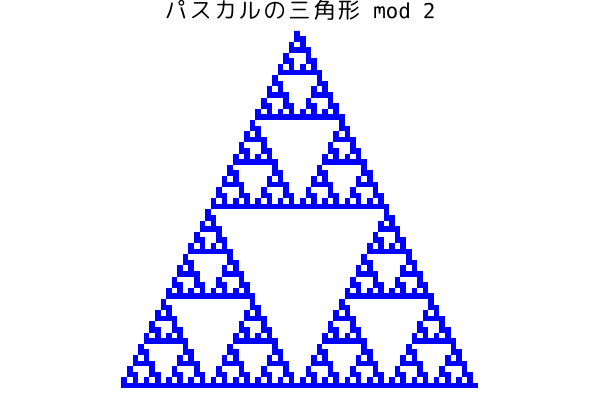

In [32]:
# 奇数の二項係数を塗る（binomial(n,r) mod 2）
N = 64
grid = zeros(Int, N, N)
for n in 0:N-1, r in 0:n
    grid[N - n, r + 1 + (N - 1 - n) ÷ 2] = binomial(big(n), big(r)) % 2
end
heatmap(grid, color=[:white, :blue], legend=false, axis=false, ticks=false,
        title="パスカルの三角形 mod 2", aspect_ratio=:equal)

**シェルピンスキーのガスケット**（フラクタル図形）が現れました!

「組合せの数」というカタい数学の中に、こんな美しい模様が隠れているのです。

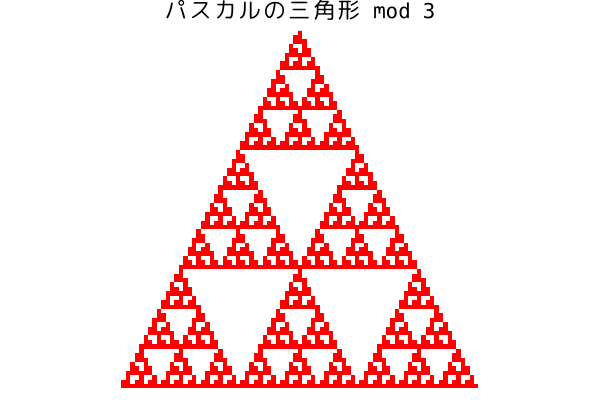

In [33]:
# おまけ：mod 3 で塗るとどうなる?
N = 81
grid = zeros(Int, N, N)
for n in 0:N-1, r in 0:n
    grid[N - n, r + 1 + (N - 1 - n) ÷ 2] = binomial(big(n), big(r)) % 3 == 0 ? 0 : 1
end
heatmap(grid, color=[:white, :red], legend=false, axis=false, ticks=false,
        title="パスカルの三角形 mod 3", aspect_ratio=:equal)

## Day 3 の演習問題

- まず全部作って表示 → 数えて → 公式と比較しよう
- ノートブックを保存して、Google Classroomから提出しよう

### 問題1: 組合せの実験

6人（A〜F）から2人選ぶ方法を**全部表示**し、個数が ${}_6\mathrm{C}_2$ と一致することを確かめよう。

### 問題2: 同じものを含む順列

「JOHOKU」の6文字を並べ替える方法は何通り?（Oが2個あることに注意）

1. `unique(permutations(...))` で全部作って数えよう
2. 公式 $\dfrac{6!}{2!}$ と一致するか確かめよう

### 問題3: サイコロ2個の実験

大小2個のサイコロを投げるとき、目の和が7になる場合を全部表示し、何通りか数えよう。

### 問題4: チャレンジ問題

パスカルの三角形で、各行の**奇数の個数**を数えてみよう（n = 0〜16）。
どんな規則がありそうか、予想を書いてみよう。（ヒント：すべて2の累乗になる!）

## 解答欄

以下のセルに解答を記入してください。

### 問題1の解答

In [34]:
# 6人から2人選ぶ



### 問題2の解答

In [35]:
# 1. JOHOKUの並べ替えを全部作って数える



In [36]:
# 2. 公式と比較



### 問題3の解答

In [37]:
# 和が7になる場合



### 問題4の解答

In [38]:
# 各行の奇数の個数



## Day 3 まとめ

今日学習した内容

- **全部作る**：多重for文で樹形図いらず
- **順列** `permutations`：${}_n\mathrm{P}_r$ の意味が「見える」
- **組合せ** `combinations`：${}_n\mathrm{C}_r$ = 並べてから同一視
- **重複順列・円順列・同じものを含む順列**：全部実験で確認
- **パスカルの三角形**：色を塗ったらフラクタルが出現!

公式は暗記するものではなく、**全部作れば意味が見えてくる**もの。

明日は関数とグラフ。数式を「描いて」最大・最小を探します!